# Valuing Callable Municipal Bonds with Longstaff-Schwartz

## A Complete Walkthrough of Monte Carlo, Hull-White, and American Option Pricing

This notebook presents a comprehensive methodology for pricing callable municipal bonds using:
1. **Hull-White Model** for interest rate dynamics
2. **Monte Carlo Simulation** for path generation
3. **Longstaff-Schwartz Algorithm** with backward induction for American option valuation

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Rectangle
import seaborn as sns
from datetime import datetime
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Import our pricing engine
import sys
sys.path.append('../src')
from ls_pricing.core.curves import YieldCurve
from ls_pricing.core.hull_white import HullWhiteModel
from ls_pricing.engine.monte_carlo import MonteCarloEngine
from ls_pricing.engine.callable_bond import CallableBondEngine
from ls_pricing.instruments.bonds import CouponBond, CallableBond

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. The Challenge: Why Callable Bonds are Complex

Callable municipal bonds present unique valuation challenges:
- **Embedded American Option**: Can be called at any time after the call protection period
- **Path Dependency**: The optimal exercise decision depends on the entire interest rate path
- **No Closed-Form Solution**: Unlike European options, we can't use Black-Scholes type formulas

Let's start by setting up a typical callable municipal bond:

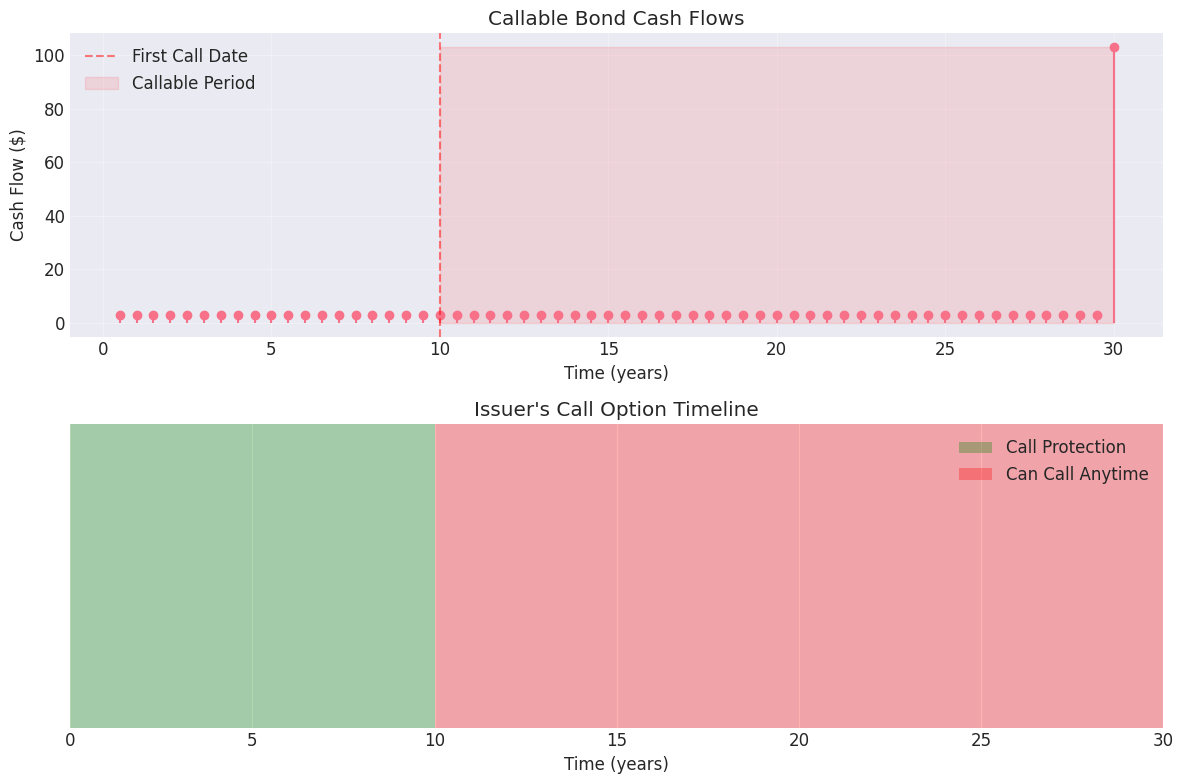


Bond Characteristics (Used Throughout This Presentation):
  Face Value: $100.0
  Coupon Rate: 6.0%
  Maturity: 30.0 years
  First Call Date: 10.0 years (30NC10)
  Call Price: $100.0 (par)
  Credit Spread: 100 bps
  Number of potential call dates: 41


In [2]:
# Create a callable municipal bond - we'll use this throughout the presentation
coupon_rate = 0.06
maturity = 30.0  # 30 years
first_call_date = 10.0  # Callable after 10 years (10NC30)
call_price = 100.0  # Callable at par
face_value = 100.0  # Face value of the bond
payment_frequency = 2  # Semi-annual payments
credit_spread = 0.01  # 100 bps credit spread
callable_bond = CallableBond(
    face_value=face_value,
    coupon_rate=coupon_rate,
    maturity=maturity,
    payment_frequency=payment_frequency,
    first_call_date=first_call_date,
    call_price=call_price,
    credit_spread=credit_spread
)

# Visualize the cash flows
times, flows = callable_bond.get_cash_flow_schedule()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top plot: Cash flow timeline
ax1.stem(times, flows, basefmt=' ')
ax1.axvline(x=callable_bond.first_call_date, color='red', linestyle='--', alpha=0.5, label='First Call Date')
ax1.fill_between([callable_bond.first_call_date, callable_bond.maturity], 0, max(flows), 
                 alpha=0.1, color='red', label='Callable Period')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Cash Flow ($)')
ax1.set_title('Callable Bond Cash Flows')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom plot: Issuer's decision timeline
ax2.add_patch(Rectangle((0, 0), callable_bond.first_call_date, 1, 
                       facecolor='green', alpha=0.3, label='Call Protection'))
ax2.add_patch(Rectangle((callable_bond.first_call_date, 0), 
                       callable_bond.maturity - callable_bond.first_call_date, 1, 
                       facecolor='red', alpha=0.3, label='Can Call Anytime'))
ax2.set_xlim(0, callable_bond.maturity)
ax2.set_ylim(0, 1)
ax2.set_xlabel('Time (years)')
ax2.set_yticks([])
ax2.set_title("Issuer's Call Option Timeline")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nBond Characteristics (Used Throughout This Presentation):")
print("="*50)
print(f"  Face Value: ${callable_bond.face_value}")
print(f"  Coupon Rate: {callable_bond.coupon_rate*100}%")
print(f"  Maturity: {callable_bond.maturity} years")
print(f"  First Call Date: {callable_bond.first_call_date} years (30NC10)")
print(f"  Call Price: ${callable_bond.call_price} (par)")
print(f"  Credit Spread: {callable_bond.credit_spread*10000:.0f} bps")
print(f"  Number of potential call dates: {len([t for t in times if t >= callable_bond.first_call_date])}")

## 2. Hull-White Model: Modeling Interest Rate Dynamics

The Hull-White model describes how short-term interest rates evolve over time:

$$dr(t) = [\theta(t) - a \cdot r(t)]dt + \sigma \cdot dW(t)$$

Where:
- $r(t)$ = short-term interest rate
- $\theta(t)$ = time-dependent drift (calibrated to market)
- $a$ = mean reversion speed
- $\sigma$ = volatility
- $dW(t)$ = Brownian motion

Let's visualize how this model works:

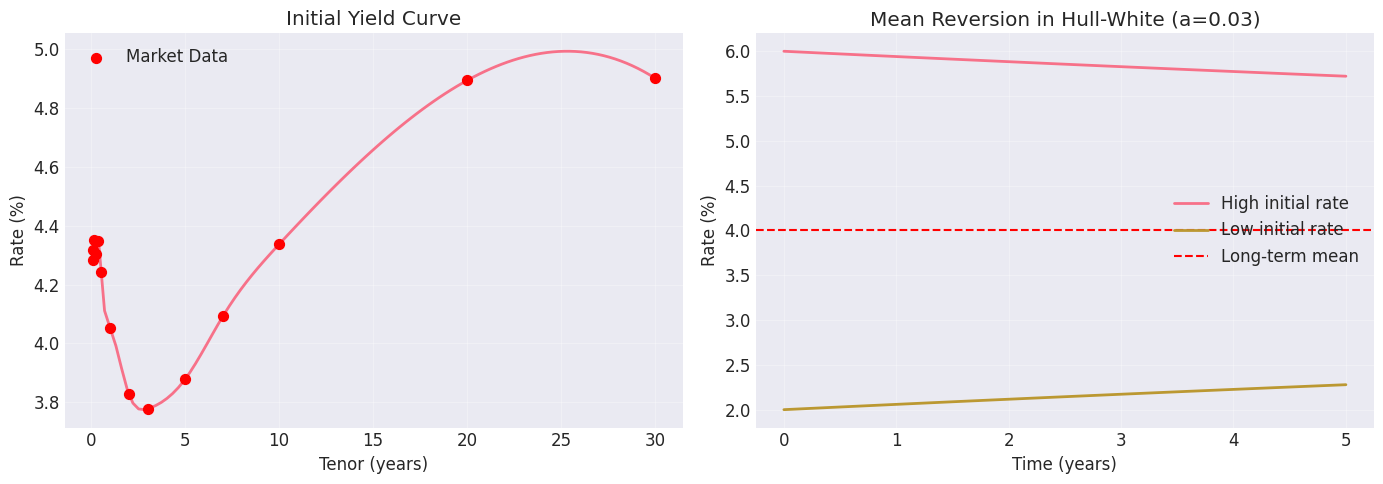


Hull-White Model Parameters:
  Mean reversion (a): 0.03
  Volatility (σ): 0.005
  Initial short rate: 4.28%


In [3]:
# Load actual Treasury curve data
treasury_data = pd.read_csv('../data/active_treasury_curve.csv', encoding='latin-1')

# Parse tenor strings to years
def tenor_to_years(tenor_str):
    if 'M' in tenor_str and 'Y' not in tenor_str:
        # Handle months
        months = int(tenor_str.replace('M', ''))
        return months / 12.0
    elif 'W' in tenor_str:
        # Handle weeks
        weeks = int(tenor_str.replace('W', ''))
        return weeks / 52.0
    elif 'Y' in tenor_str:
        # Handle years
        return float(tenor_str.replace('Y', ''))
    else:
        return None

# Extract and convert data
treasury_data['TenorYears'] = treasury_data['Tenor'].apply(tenor_to_years)
treasury_data['YieldDecimal'] = treasury_data['Yield'] / 100.0

# Filter out any rows with invalid tenor conversions and sort by tenor
valid_data = treasury_data.dropna(subset=['TenorYears']).sort_values('TenorYears')

# Extract tenors and rates
tenors = valid_data['TenorYears'].values
rates = valid_data['YieldDecimal'].values

# Create yield curve
curve_date = datetime(2025, 7, 22)
yield_curve = YieldCurve(tenors, rates, curve_date)

# Create Hull-White model
a = 0.03      # Mean reversion speed
sigma = 0.005  # Volatility
hw_model = HullWhiteModel(a=a, sigma=sigma, yield_curve=yield_curve)

# Visualize the yield curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Yield Curve
plot_tenors = np.linspace(0.1, 30, 100)
plot_rates = [yield_curve.get_rate(t) for t in plot_tenors]
ax1.plot(plot_tenors, np.array(plot_rates)*100, linewidth=2)
ax1.scatter(tenors, rates*100, color='red', s=50, zorder=5, label='Market Data')
ax1.set_xlabel('Tenor (years)')
ax1.set_ylabel('Rate (%)')
ax1.set_title('Initial Yield Curve')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Mean Reversion Illustration
t = np.linspace(0, 5, 100)
r_start_high = 0.06
r_start_low = 0.02
r_target = 0.04

# Mean reversion paths (simplified, no randomness)
r_high = r_target + (r_start_high - r_target) * np.exp(-a * t)
r_low = r_target + (r_start_low - r_target) * np.exp(-a * t)

ax2.plot(t, r_high*100, label='High initial rate', linewidth=2)
ax2.plot(t, r_low*100, label='Low initial rate', linewidth=2)
ax2.axhline(y=r_target*100, color='red', linestyle='--', label='Long-term mean')
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Rate (%)')
ax2.set_title(f'Mean Reversion in Hull-White (a={a})')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nHull-White Model Parameters:")
print(f"  Mean reversion (a): {a}")
print(f"  Volatility (σ): {sigma}")
print(f"  Initial short rate: {yield_curve.get_rate(0)*100:.2f}%")

## 3. Monte Carlo Simulation: Generating Interest Rate Paths

Now let's simulate multiple interest rate paths using Monte Carlo. Each path represents a possible future evolution of rates:

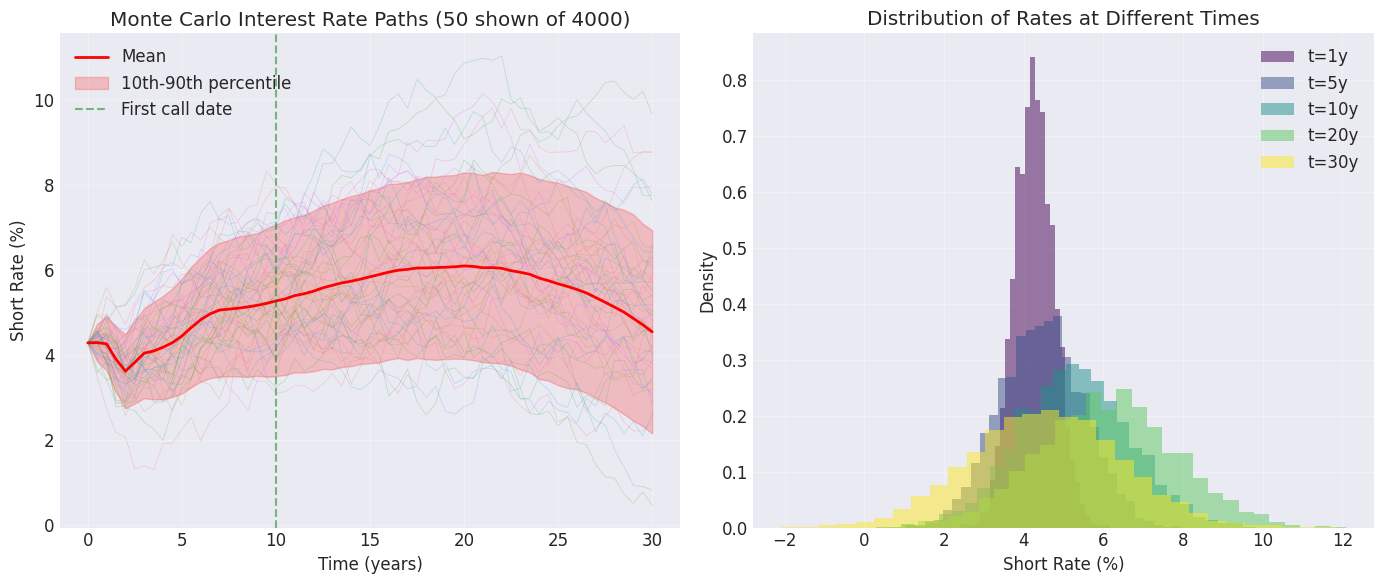


Monte Carlo Simulation Statistics:
  Number of paths: 4000
  Time steps: 60
  Mean rate at maturity: 4.54%
  Std dev at maturity: 1.88%


In [4]:
# Create Monte Carlo engine
n_paths = 4000
n_steps = 60  # Semi-annual steps for 30 years
mc_engine = MonteCarloEngine(model=hw_model, n_paths=n_paths, n_steps=n_steps)

# Generate paths
paths = mc_engine.generate_paths(T=callable_bond.maturity, seed=42)
rates = paths['rates']
times = paths['times']

# Visualize the paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Sample paths
n_display = 50
for i in range(n_display):
    ax1.plot(times, rates[i, :]*100, alpha=0.3, linewidth=0.5)

# Add mean and percentiles
mean_path = np.mean(rates, axis=0)
p10 = np.percentile(rates, 10, axis=0)
p90 = np.percentile(rates, 90, axis=0)

ax1.plot(times, mean_path*100, 'r-', linewidth=2, label='Mean')
ax1.fill_between(times, p10*100, p90*100, alpha=0.2, color='red', label='10th-90th percentile')
ax1.axvline(x=callable_bond.first_call_date, color='green', linestyle='--', alpha=0.5, label='First call date')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Short Rate (%)')
ax1.set_title(f'Monte Carlo Interest Rate Paths ({n_display} shown of {n_paths})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution at different times
time_points = [1, 5, 10, 20, 30]
colors = plt.cm.viridis(np.linspace(0, 1, len(time_points)))

for idx, t in enumerate(time_points):
    time_idx = np.argmin(np.abs(times - t))
    rates_at_t = rates[:, time_idx]
    ax2.hist(rates_at_t*100, bins=30, alpha=0.5, density=True, 
             label=f't={t}y', color=colors[idx])

ax2.set_xlabel('Short Rate (%)')
ax2.set_ylabel('Density')
ax2.set_title('Distribution of Rates at Different Times')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMonte Carlo Simulation Statistics:")
print(f"  Number of paths: {n_paths}")
print(f"  Time steps: {n_steps}")
print(f"  Mean rate at maturity: {mean_path[-1]*100:.2f}%")
print(f"  Std dev at maturity: {np.std(rates[:, -1])*100:.2f}%")

## 4. The Issuer's Optimal Call Decision

At each potential call date, the issuer faces a decision:
- **Call the bond**: Pay the call price immediately
- **Don't call**: Continue paying coupons and face the same decision later

The optimal decision depends on:
1. Current interest rates (can they refinance cheaper?)
2. Future rate expectations (will rates go even lower?)

Let's visualize this decision process:

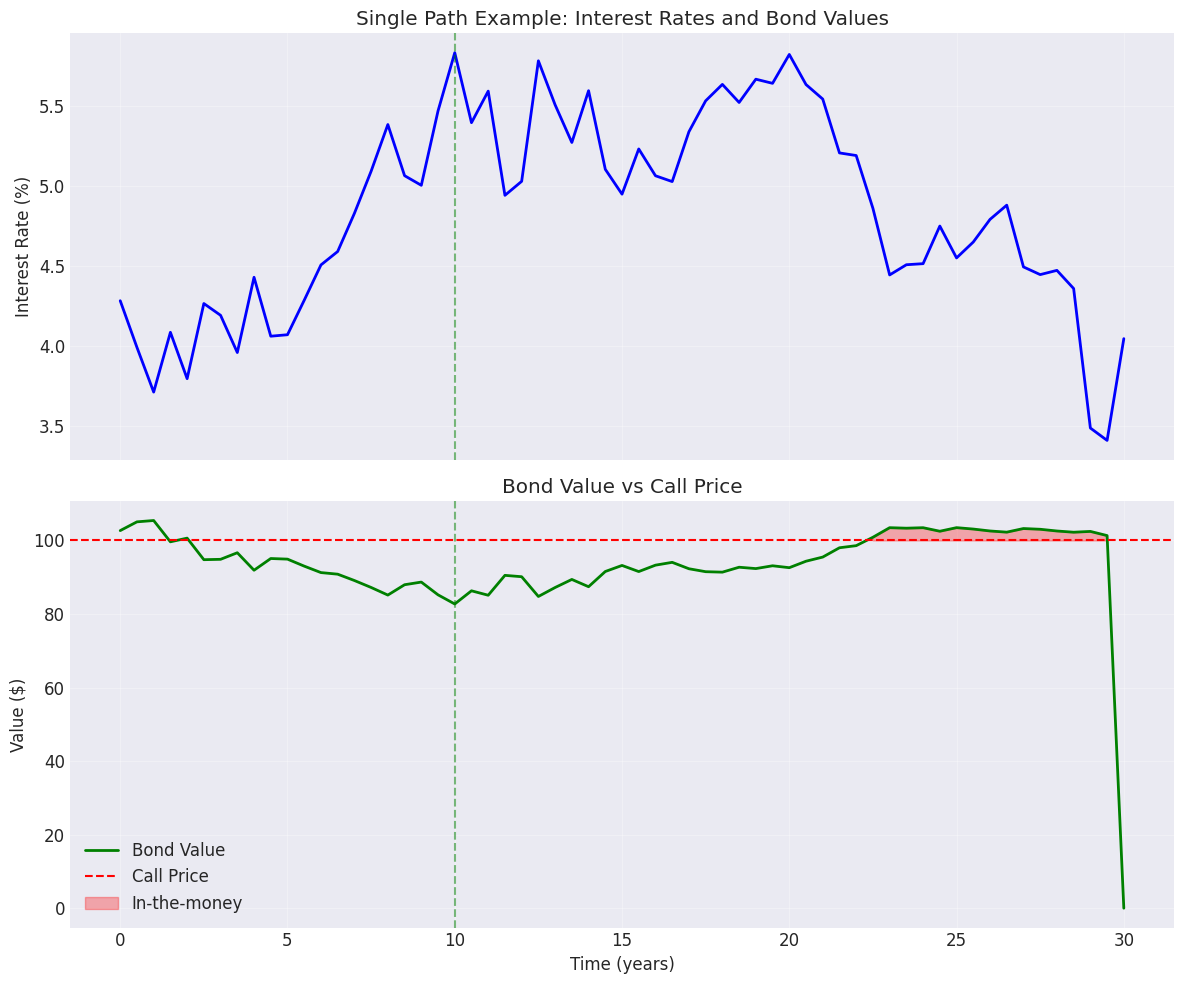


First time bond is in-the-money: 22.5 years
Bond value at that time: $100.87
Immediate gain from calling: $0.87


In [5]:
# Calculate bond values along a single path
path_idx = 60  # Choose a specific path
single_path_rates = rates[path_idx, :]

# Calculate bond value at each time step
bond_values = []
for i, t in enumerate(times):
    if t <= callable_bond.maturity:
        bond_value = callable_bond.value(hw_model, t, single_path_rates[i])
        bond_values.append(bond_value)
    else:
        bond_values.append(0)

bond_values = np.array(bond_values)

# Visualize the decision
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top: Interest rate path
ax1.plot(times, single_path_rates*100, 'b-', linewidth=2)
ax1.axvline(x=callable_bond.first_call_date, color='green', linestyle='--', alpha=0.5)
ax1.set_ylabel('Interest Rate (%)')
ax1.set_title('Single Path Example: Interest Rates and Bond Values')
ax1.grid(True, alpha=0.3)

# Bottom: Bond value and call decision
ax2.plot(times, bond_values, 'g-', linewidth=2, label='Bond Value')
ax2.axhline(y=callable_bond.call_price, color='red', linestyle='--', label='Call Price')
ax2.fill_between(times, bond_values, callable_bond.call_price, 
                 where=(bond_values > callable_bond.call_price) & (times >= callable_bond.first_call_date),
                 alpha=0.3, color='red', label='In-the-money')
ax2.axvline(x=callable_bond.first_call_date, color='green', linestyle='--', alpha=0.5)
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Value ($)')
ax2.set_title('Bond Value vs Call Price')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find first time bond is callable and in-the-money
callable_times = times[times >= callable_bond.first_call_date]
callable_values = bond_values[times >= callable_bond.first_call_date]
first_itm_idx = np.where(callable_values > callable_bond.call_price)[0]

if len(first_itm_idx) > 0:
    first_itm_time = callable_times[first_itm_idx[0]]
    first_itm_value = callable_values[first_itm_idx[0]]
    print(f"\nFirst time bond is in-the-money: {first_itm_time:.1f} years")
    print(f"Bond value at that time: ${first_itm_value:.2f}")
    print(f"Immediate gain from calling: ${first_itm_value - callable_bond.call_price:.2f}")
else:
    print("\nBond never goes in-the-money on this path")

## 5. The Longstaff-Schwartz Algorithm: Estimating Continuation Values

The key insight of Longstaff-Schwartz is to use **regression** to estimate the expected continuation value at each decision point.

### The Algorithm:
1. Start at maturity and work backwards (backward induction)
2. At each call date, for paths where the bond is in-the-money:
   - **Immediate exercise value** = Bond Value - Call Price
   - **Continuation value** = Expected future cash flows (estimated via regression)
3. Exercise if immediate value > continuation value

Let's implement this step-by-step:

Running Longstaff-Schwartz algorithm...

Analyzing exercise decision at t=20.0 years...


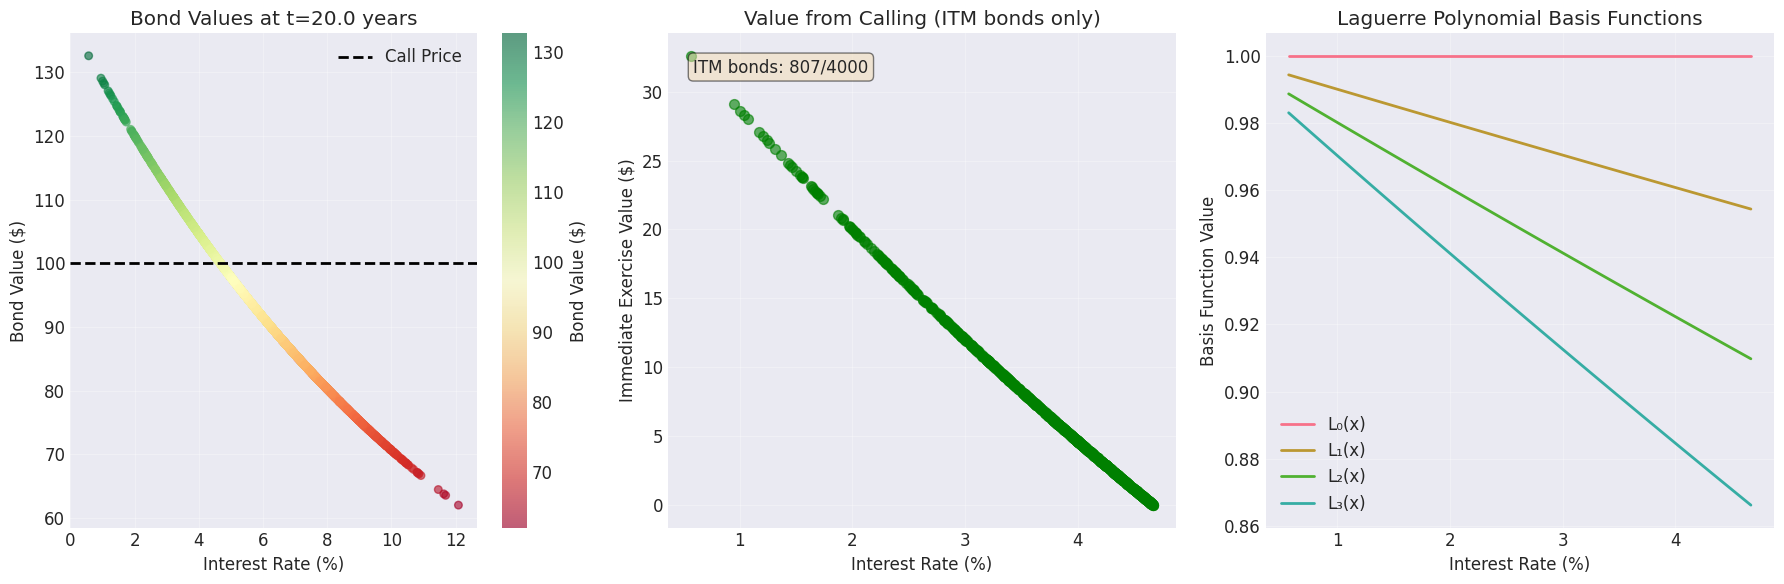


Longstaff-Schwartz Decision Process at t=20.0:
1. For each in-the-money path, we have two choices:
   - Exercise now: Get immediate value = Bond Value - 100.0
   - Continue: Get expected future cash flows (estimated via regression)

2. The regression estimates E[Future Cash Flows | Current Rate]
   using polynomial basis functions of the current interest rate

3. Exercise if: Immediate Value > Continuation Value

4. At this time: 807 out of 4000 paths are ITM

5. Actual results at t=20.0:
   - Call probability: 14.8%
   - Mean rate when called: 3.41%
   - Mean bond value when called: $109.09


In [6]:
# Real Longstaff-Schwartz demonstration
# Let's show how the algorithm actually works at a specific time point

# First, price the bond to get the exercise boundary information
cb_engine = CallableBondEngine(
    mc_engine=mc_engine,
    basis_type='laguerre',
    basis_degree=3
)

# Generate paths and price
print("Running Longstaff-Schwartz algorithm...")
cb_engine.generate_paths(callable_bond.maturity, seed=42)
result = cb_engine.price_callable_bond(callable_bond)

# Now let's look inside the algorithm at a specific time point
# Choose year 20 (middle of callable period)
target_time = 20.0
time_idx = np.argmin(np.abs(times - target_time))
current_time = times[time_idx]

# Get the rates at this time for all paths
current_rates = rates[:, time_idx]

# Calculate bond values for all paths at this time
print(f"\nAnalyzing exercise decision at t={current_time:.1f} years...")
bond_values_at_t = callable_bond.value_at_node(
    hw_model, 
    current_time, 
    current_rates
)

# Identify in-the-money paths
itm_mask = bond_values_at_t > callable_bond.call_price
immediate_exercise_value = bond_values_at_t - callable_bond.call_price

# The key insight: We need to compare immediate exercise vs continuation
# In the actual algorithm, continuation values come from the future optimal values
# Let's visualize this decision process

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Bond values vs rates
scatter1 = ax1.scatter(current_rates*100, bond_values_at_t, 
                      c=bond_values_at_t, cmap='RdYlGn', alpha=0.6, s=30)
ax1.axhline(y=callable_bond.call_price, color='black', linestyle='--', linewidth=2, label='Call Price')
ax1.set_xlabel('Interest Rate (%)')
ax1.set_ylabel('Bond Value ($)')
ax1.set_title(f'Bond Values at t={current_time:.1f} years')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Bond Value ($)')

# Plot 2: Exercise value for ITM bonds
if np.sum(itm_mask) > 0:
    ax2.scatter(current_rates[itm_mask]*100, immediate_exercise_value[itm_mask], 
               alpha=0.6, s=50, color='green')
    ax2.set_xlabel('Interest Rate (%)')
    ax2.set_ylabel('Immediate Exercise Value ($)')
    ax2.set_title('Value from Calling (ITM bonds only)')
    ax2.grid(True, alpha=0.3)
    
    # Add some statistics
    ax2.text(0.05, 0.95, f'ITM bonds: {np.sum(itm_mask)}/{len(itm_mask)}', 
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    ax2.text(0.5, 0.5, 'No bonds in-the-money\nat this time', 
            ha='center', va='center', transform=ax2.transAxes)

# Plot 3: The regression concept
# Show how we use polynomial basis functions of the state variable (interest rate)
if np.sum(itm_mask) > 10:  # Need enough points
    X = current_rates[itm_mask]
    
    # Create Laguerre polynomial basis (what the actual algorithm uses)
    from numpy.polynomial.laguerre import Laguerre
    basis_functions = []
    for degree in range(4):
        basis_functions.append(Laguerre.basis(degree)(np.exp(-X/2) * X))
    
    # Plot the basis functions
    X_plot = np.linspace(X.min(), X.max(), 100)
    for i, basis in enumerate(['L₀', 'L₁', 'L₂', 'L₃']):
        basis_values = Laguerre.basis(i)(np.exp(-X_plot/2) * X_plot)
        ax3.plot(X_plot*100, basis_values, label=f'{basis}(x)', linewidth=2)
    
    ax3.set_xlabel('Interest Rate (%)')
    ax3.set_ylabel('Basis Function Value')
    ax3.set_title('Laguerre Polynomial Basis Functions')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Not enough ITM bonds\nfor regression', 
            ha='center', va='center', transform=ax3.transAxes)

plt.tight_layout()
plt.show()

# Show the decision process
print(f"\nLongstaff-Schwartz Decision Process at t={current_time}:")
print("="*60)
print("1. For each in-the-money path, we have two choices:")
print(f"   - Exercise now: Get immediate value = Bond Value - {callable_bond.call_price}")
print("   - Continue: Get expected future cash flows (estimated via regression)")
print("\n2. The regression estimates E[Future Cash Flows | Current Rate]")
print("   using polynomial basis functions of the current interest rate")
print("\n3. Exercise if: Immediate Value > Continuation Value")
print(f"\n4. At this time: {np.sum(itm_mask)} out of {len(itm_mask)} paths are ITM")

# Show actual results from our pricing
if 'exercise_boundary' in result and current_time in result['exercise_boundary']:
    boundary_info = result['exercise_boundary'][current_time]
    print(f"\n5. Actual results at t={current_time}:")
    print(f"   - Call probability: {boundary_info['call_probability']*100:.1f}%")
    print(f"   - Mean rate when called: {boundary_info['mean_rate']*100:.2f}%")
    print(f"   - Mean bond value when called: ${boundary_info['mean_bond_value']:.2f}")

## 6. Backward Induction: Working Through Time

The complete algorithm works backwards from maturity to the present. Let's visualize this process:

Pricing callable bond using full Longstaff-Schwartz algorithm...


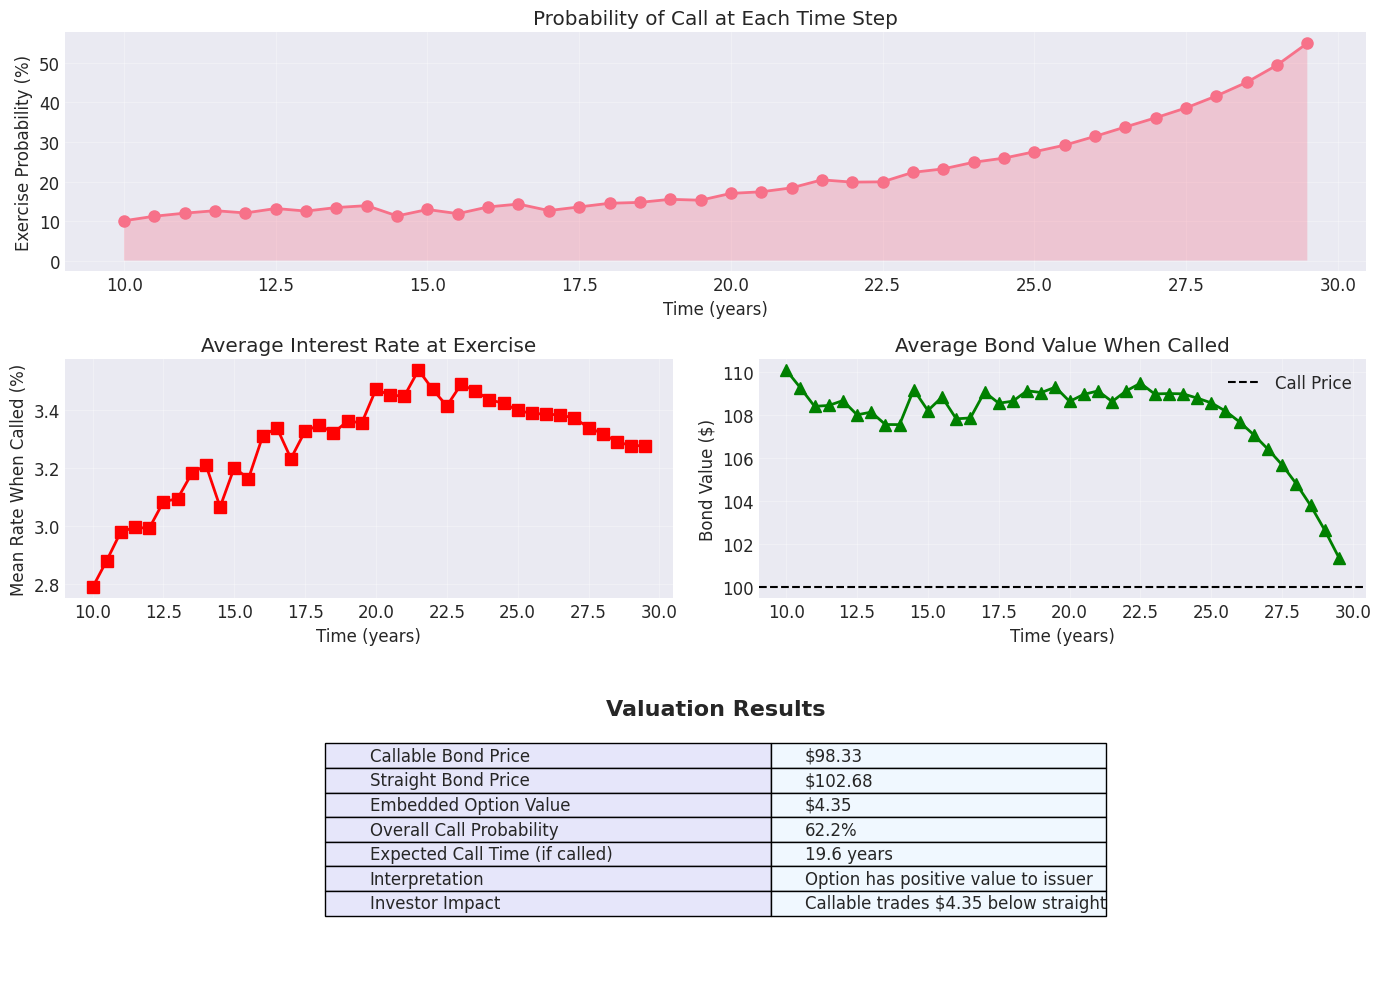

In [ ]:
# Create the full pricing engine
cb_engine = CallableBondEngine(
    mc_engine=mc_engine,
    basis_type='laguerre',
    basis_degree=3
)

# Price the callable bond
print("Pricing callable bond using full Longstaff-Schwartz algorithm...")
result = cb_engine.price_callable_bond(callable_bond)

# Extract exercise boundary information
exercise_boundary = result['exercise_boundary']

# Visualize the backward induction process
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2])

# Plot 1: Exercise probability over time
ax1 = fig.add_subplot(gs[0, :])
if exercise_boundary:
    ex_times = sorted(exercise_boundary.keys())
    ex_probs = [exercise_boundary[t]['call_probability'] for t in ex_times]
    
    ax1.plot(ex_times, np.array(ex_probs)*100, 'o-', linewidth=2, markersize=8)
    ax1.fill_between(ex_times, 0, np.array(ex_probs)*100, alpha=0.3)
    ax1.set_xlabel('Time (years)')
    ax1.set_ylabel('Exercise Probability (%)')
    ax1.set_title('Probability of Call at Each Time Step')
    ax1.grid(True, alpha=0.3)

# Plot 2: Critical rate boundary
ax2 = fig.add_subplot(gs[1, 0])
if exercise_boundary:
    critical_rates = [exercise_boundary[t]['mean_rate'] for t in ex_times]
    
    ax2.plot(ex_times, np.array(critical_rates)*100, 's-', linewidth=2, markersize=8, color='red')
    ax2.set_xlabel('Time (years)')
    ax2.set_ylabel('Mean Rate When Called (%)')
    ax2.set_title('Average Interest Rate at Exercise')
    ax2.grid(True, alpha=0.3)

# Plot 3: Bond value distribution at call
ax3 = fig.add_subplot(gs[1, 1])
if exercise_boundary:
    bond_values_at_call = [exercise_boundary[t]['mean_bond_value'] for t in ex_times]
    
    ax3.plot(ex_times, bond_values_at_call, '^-', linewidth=2, markersize=8, color='green')
    ax3.axhline(y=callable_bond.call_price, color='black', linestyle='--', label='Call Price')
    ax3.set_xlabel('Time (years)')
    ax3.set_ylabel('Bond Value ($)')
    ax3.set_title('Average Bond Value When Called')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# Plot 4: Summary results
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

# Create summary table
summary_data = [
    ['Callable Bond Price', f"${result['callable_bond_price']:.2f}"],
    ['Straight Bond Price', f"${result['straight_bond_price']:.2f}"],
    ['Embedded Option Value', f"${result['option_value']:.2f}"],
    ['Overall Call Probability', f"{result['exercise_probability']*100:.1f}%"],
    ['Expected Call Time (if called)', f"{result['mean_call_time']:.1f} years"]
]

# Add interpretation
if result['option_value'] > 0:
    summary_data.append(['Interpretation', 'Option has positive value to issuer'])
    summary_data.append(['Investor Impact', f"Callable trades ${result['option_value']:.2f} below straight"])

table = ax4.table(cellText=summary_data, cellLoc='left', loc='center',
                  colWidths=[0.4, 0.3], bbox=[0.2, 0.2, 0.6, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

# Style the table
for i in range(len(summary_data)):
    table[(i, 0)].set_facecolor('#E6E6FA')
    table[(i, 1)].set_facecolor('#F0F8FF')

ax4.text(0.5, 0.9, 'Valuation Results', fontsize=16, fontweight='bold',
         ha='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()

## 7. Understanding the Results: Why This Matters

Let's analyze how different factors affect the callable bond value:

Running sensitivity analysis...
(Using same bond structure, only varying coupon rate)


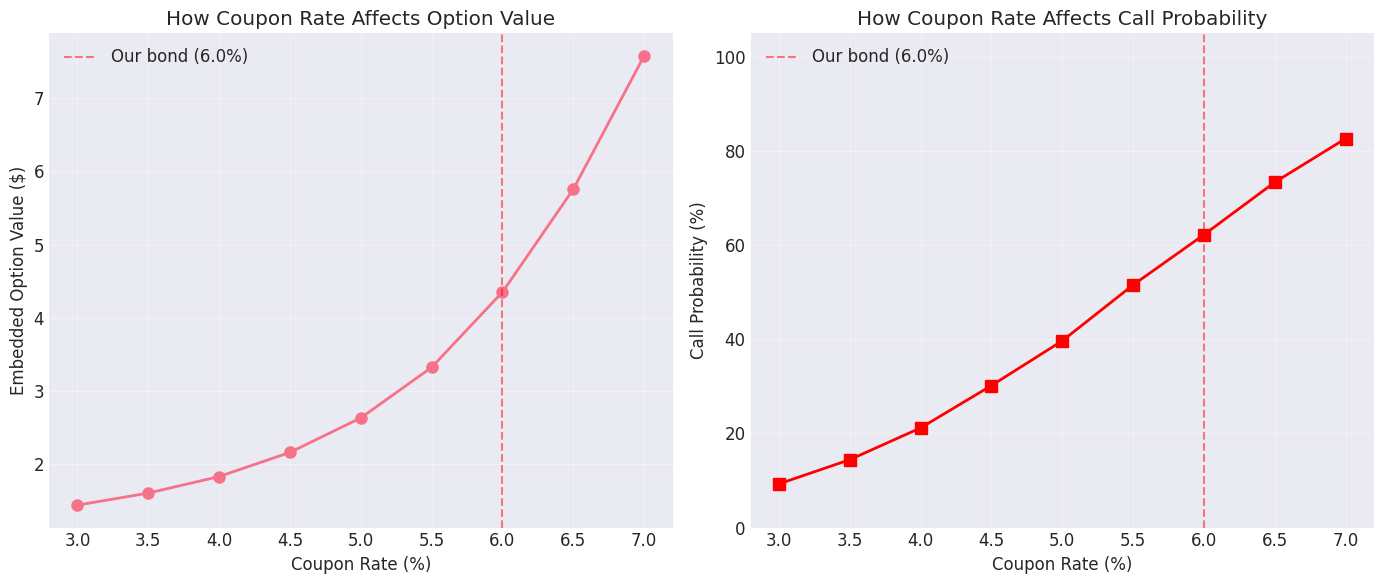


Key Insights:
1. Higher coupon bonds are more likely to be called
2. The embedded option is more valuable for high-coupon bonds
3. Investors demand larger discounts for high-coupon callable bonds

For our 6.0% coupon bond:
  Option value: $4.35
  Call probability: 62.2%


In [8]:
# Sensitivity analysis: How does coupon rate affect option value?
# We'll vary the coupon rate while keeping everything else constant
coupon_rates = np.arange(0.03, 0.07, 0.005)
option_values = []
call_probabilities = []

print("Running sensitivity analysis...")
print("(Using same bond structure, only varying coupon rate)")

for coupon in coupon_rates:
    test_bond = CallableBond(
    face_value=face_value,
    coupon_rate=coupon,
    maturity=maturity,
    payment_frequency=payment_frequency,
    first_call_date=first_call_date,
    call_price=call_price,
    credit_spread=credit_spread
)
    
    res = cb_engine.price_callable_bond(test_bond)
    option_values.append(res['option_value'])
    call_probabilities.append(res['exercise_probability'])

# Visualize sensitivity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Option value vs coupon
ax1.plot(coupon_rates*100, option_values, 'o-', linewidth=2, markersize=8)
ax1.axvline(x=callable_bond.coupon_rate*100, color='red', linestyle='--', alpha=0.5, 
            label=f'Our bond ({callable_bond.coupon_rate*100}%)')
ax1.set_xlabel('Coupon Rate (%)')
ax1.set_ylabel('Embedded Option Value ($)')
ax1.set_title('How Coupon Rate Affects Option Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Call probability vs coupon
ax2.plot(coupon_rates*100, np.array(call_probabilities)*100, 's-', 
         linewidth=2, markersize=8, color='red')
ax2.axvline(x=callable_bond.coupon_rate*100, color='red', linestyle='--', alpha=0.5,
            label=f'Our bond ({callable_bond.coupon_rate*100}%)')
ax2.set_xlabel('Coupon Rate (%)')
ax2.set_ylabel('Call Probability (%)')
ax2.set_title('How Coupon Rate Affects Call Probability')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("1. Higher coupon bonds are more likely to be called")
print("2. The embedded option is more valuable for high-coupon bonds")
print("3. Investors demand larger discounts for high-coupon callable bonds")
print(f"\nFor our {callable_bond.coupon_rate*100}% coupon bond:")
idx_our_bond = np.argmin(np.abs(coupon_rates - callable_bond.coupon_rate))
print(f"  Option value: ${option_values[idx_our_bond]:.2f}")
print(f"  Call probability: {call_probabilities[idx_our_bond]*100:.1f}%")

## 8. The Complete Picture: From Theory to Practice

Let's summarize the complete valuation process with a visual flowchart:

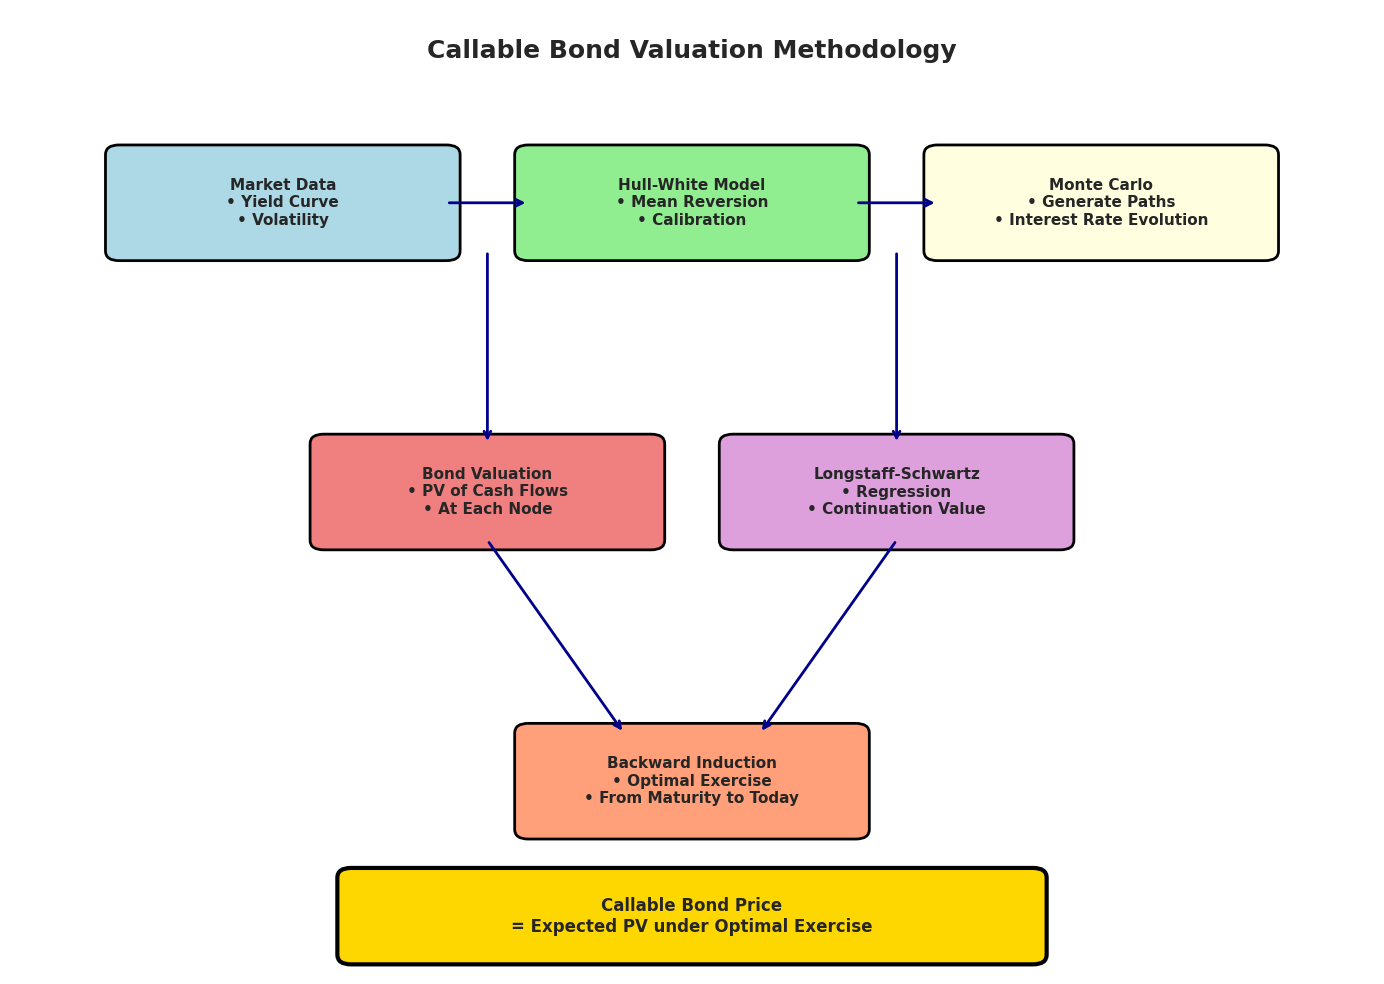


SUMMARY: Callable Bond Valuation using Longstaff-Schwartz

The complete methodology combines:

1. HULL-WHITE MODEL
   - Models interest rate dynamics with mean reversion
   - Calibrated to current yield curve

2. MONTE CARLO SIMULATION
   - Generates thousands of possible rate paths
   - Captures uncertainty in future rates

3. LONGSTAFF-SCHWARTZ ALGORITHM
   - Uses regression to estimate continuation values
   - Compares immediate exercise vs. waiting

4. BACKWARD INDUCTION
   - Works backwards from maturity
   - Finds optimal exercise strategy

RESULT: Fair value that reflects the embedded optionality

For our example bond:
  Callable price: $98.33
  Option value: $4.35
  This means investors demand a $4.35 discount
  to compensate for the call risk.


In [9]:
# Create a visual summary of the methodology
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

# Define box positions
boxes = [
    {'name': 'Market Data\n• Yield Curve\n• Volatility', 'pos': (0.2, 0.8), 'color': 'lightblue'},
    {'name': 'Hull-White Model\n• Mean Reversion\n• Calibration', 'pos': (0.5, 0.8), 'color': 'lightgreen'},
    {'name': 'Monte Carlo\n• Generate Paths\n• Interest Rate Evolution', 'pos': (0.8, 0.8), 'color': 'lightyellow'},
    {'name': 'Bond Valuation\n• PV of Cash Flows\n• At Each Node', 'pos': (0.35, 0.5), 'color': 'lightcoral'},
    {'name': 'Longstaff-Schwartz\n• Regression\n• Continuation Value', 'pos': (0.65, 0.5), 'color': 'plum'},
    {'name': 'Backward Induction\n• Optimal Exercise\n• From Maturity to Today', 'pos': (0.5, 0.2), 'color': 'lightsalmon'},
]

# Draw boxes
from matplotlib.patches import FancyBboxPatch
for box in boxes:
    bbox = FancyBboxPatch(
        (box['pos'][0] - 0.12, box['pos'][1] - 0.05),
        0.24, 0.1,
        boxstyle="round,pad=0.01",
        facecolor=box['color'],
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(bbox)
    ax.text(box['pos'][0], box['pos'][1], box['name'], 
            ha='center', va='center', fontsize=11, weight='bold')

# Draw arrows
arrows = [
    ((0.32, 0.8), (0.38, 0.8)),
    ((0.62, 0.8), (0.68, 0.8)),
    ((0.35, 0.75), (0.35, 0.55)),
    ((0.65, 0.75), (0.65, 0.55)),
    ((0.35, 0.45), (0.45, 0.25)),
    ((0.65, 0.45), (0.55, 0.25)),
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', lw=2, color='darkblue'))

# Add title
ax.text(0.5, 0.95, 'Callable Bond Valuation Methodology', 
        fontsize=18, weight='bold', ha='center')

# Add result box
result_box = FancyBboxPatch(
    (0.25, 0.02),
    0.5, 0.08,
    boxstyle="round,pad=0.01",
    facecolor='gold',
    edgecolor='black',
    linewidth=3
)
ax.add_patch(result_box)
ax.text(0.5, 0.06, 'Callable Bond Price\n= Expected PV under Optimal Exercise', 
        ha='center', va='center', fontsize=12, weight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "="*60)
print("SUMMARY: Callable Bond Valuation using Longstaff-Schwartz")
print("="*60)
print("\nThe complete methodology combines:")
print("\n1. HULL-WHITE MODEL")
print("   - Models interest rate dynamics with mean reversion")
print("   - Calibrated to current yield curve")
print("\n2. MONTE CARLO SIMULATION")
print("   - Generates thousands of possible rate paths")
print("   - Captures uncertainty in future rates")
print("\n3. LONGSTAFF-SCHWARTZ ALGORITHM")
print("   - Uses regression to estimate continuation values")
print("   - Compares immediate exercise vs. waiting")
print("\n4. BACKWARD INDUCTION")
print("   - Works backwards from maturity")
print("   - Finds optimal exercise strategy")
print("\nRESULT: Fair value that reflects the embedded optionality")
print(f"\nFor our example bond:")
print(f"  Callable price: ${result['callable_bond_price']:.2f}")
print(f"  Option value: ${result['option_value']:.2f}")
print(f"  This means investors demand a ${result['option_value']:.2f} discount")
print(f"  to compensate for the call risk.")

## Conclusion

This notebook has demonstrated the complete process of valuing callable municipal bonds using the Longstaff-Schwartz method:

1. We modeled interest rates using the Hull-White model
2. Generated Monte Carlo paths to capture future uncertainty  
3. Applied the Longstaff-Schwartz algorithm to find optimal exercise decisions
4. Used backward induction to value the embedded option

The key insight is that American options (like the call feature in bonds) require sophisticated numerical methods because:
- The exercise decision is path-dependent
- No closed-form solution exists
- The issuer's optimal strategy must be determined endogenously

This methodology is essential for proper risk management and pricing in the municipal bond market.